In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt


# 1) Oracle Summaries laden
oracle_dir = Path("./results_merged")  # anpassen
files = sorted(oracle_dir.glob("summary_*.csv"))

oracle = pd.concat(
    (pd.read_csv(f, parse_dates=["day"]) for f in files),
    ignore_index=True
)

# Vereinheitlichen: nur Datum
#oracle["day"] = pd.to_datetime(oracle["day"], errors="coerce").dt.normalize()

oracle["day"] = pd.to_datetime(oracle["day"].astype(str).str.slice(0, 10), errors="coerce")
oracle["day"] = oracle["day"].dt.normalize()

# 2) RI_base aus combo_id==0 ziehen
ri_base = (
    oracle.loc[oracle["combo_id"] == 0, ["day", "profit"]]
    .rename(columns={"profit": "RI_base"})
    .drop_duplicates(subset=["day"])
)

# 2b) Myopic Baseline: für jeden Tag die Kombination mit maximalem da_profit
myopic_base = (
    oracle.sort_values("da_profit", ascending=False)
    .groupby("day", as_index=False)
    .first()[["day", "profit"]]
    .rename(columns={"profit": "myopic_base"})
)

# 3) Alle "synthetic" Runs (ohne combo 0)
syn = oracle.loc[oracle["combo_id"] != 0].copy()

# 4) Baseline an synthetic dranhängen
syn = syn.merge(ri_base, on="day", how="left")

# Prozentualer uplift je combo
syn["uplift_pct"] = (syn["profit"] - syn["RI_base"]) / syn["RI_base"] * 100

# 5) Tages-Übersicht bauen (RI-Baseline)
summary = (
    syn.groupby("day")
    .apply(lambda g: pd.Series({
        "RI_base": g["RI_base"].iloc[0],
        "Oracle_max": g["profit"].max(),
        "Oracle_max_pct": (g["profit"].max() - g["RI_base"].iloc[0]) / g["RI_base"].iloc[0] * 100,
        "n_better_than_base": (g["profit"] > g["RI_base"]).sum(),
        "mean_uplift": g["uplift_pct"].mean(),
        "median_uplift": g["uplift_pct"].median(),
        "mean_uplift_pct_if_better": g.loc[g["profit"] > g["RI_base"], "uplift_pct"].mean(),
        "median_uplift_pct_if_better": g.loc[g["profit"] > g["RI_base"], "uplift_pct"].median(),
    }))
    .reset_index()
)

# Optional: NaNs (falls kein Run besser ist) auf 0 setzen
summary[["mean_uplift_pct_if_better", "median_uplift_pct_if_better"]] = (
    summary[["mean_uplift_pct_if_better", "median_uplift_pct_if_better"]].fillna(0.0)
)

# Speichern RI-Baseline
out_path = oracle_dir / "oracle_overview_by_day.csv"
summary.to_csv(out_path, index=False)

print("Saved:", out_path)


# === Myopic-Baseline-Auswertung ===
# Baseline an alle Kombinationen (inkl. combo_id==0) mergen
syn_myopic = oracle.merge(myopic_base, on="day", how="left")

# Prozentualer uplift je combo relativ zur myopic_base
syn_myopic["uplift_pct_myopic"] = (
    (syn_myopic["profit"] - syn_myopic["myopic_base"]) / syn_myopic["myopic_base"] * 100
)

# Tages-Übersicht für myopic_base
summary_myopic = (
    syn_myopic.groupby("day")
    .apply(lambda g: pd.Series({
        "myopic_base": g["myopic_base"].iloc[0],
        "Oracle_max": g["profit"].max(),
        "Oracle_max_pct": (g["profit"].max() - g["myopic_base"].iloc[0]) / g["myopic_base"].iloc[0] * 100,
        "n_better_than_base": (g["profit"] > g["myopic_base"]).sum(),
        "mean_uplift": g["uplift_pct_myopic"].mean(),
        "median_uplift": g["uplift_pct_myopic"].median(),
        "mean_uplift_pct_if_better": g.loc[g["profit"] > g["myopic_base"], "uplift_pct_myopic"].mean(),
        "median_uplift_pct_if_better": g.loc[g["profit"] > g["myopic_base"], "uplift_pct_myopic"].median(),
    }))
    .reset_index()
)

summary_myopic[["mean_uplift_pct_if_better", "median_uplift_pct_if_better"]] = (
    summary_myopic[["mean_uplift_pct_if_better", "median_uplift_pct_if_better"]].fillna(0.0)
)

# Speichern Myopic-Baseline
out_path_myopic = oracle_dir / "oracle_overview_by_day_myopic.csv"
summary_myopic.to_csv(out_path_myopic, index=False)

print("Saved (myopic base):", out_path_myopic)

/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_98653/4154578144.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


Saved: results_merged/oracle_overview_by_day.csv
Saved (myopic base): results_merged/oracle_overview_by_day_myopic.csv


/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_98653/4154578144.py:86: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [4]:
summary.describe().round(2)
summary.drop(columns=["day","median_uplift", "median_uplift_pct_if_better"]).describe().round(2)

,RI_base,Oracle_max,Oracle_max_pct,n_better_than_base,mean_uplift,mean_uplift_pct_if_better
count,2494.00,2494.00,2494.00,2494.00,2494.00,2494.00
mean,184.54,216.26,22.80,126.77,-2.48,7.53
std,157.56,177.18,30.64,78.63,14.49,12.41
min,17.54,30.75,-5.39,0.00,-48.67,0.00
25%,84.89,104.69,10.00,59.00,-7.37,3.10
50%,145.28,170.91,15.52,122.00,-1.68,4.94
75%,234.38,270.64,26.05,189.00,1.99,8.30
max,2375.53,2589.57,750.58,299.00,401.20,402.56


In [5]:
summary_myopic.describe().round(2)
summary_myopic.drop(columns=["day","median_uplift", "median_uplift_pct_if_better"]).describe().round(2)

,myopic_base,Oracle_max,Oracle_max_pct,n_better_than_base,mean_uplift,mean_uplift_pct_if_better
count,2494.00,2494.00,2494.00,2494.00,2494.00,2494.00
mean,186.01,216.27,20.70,110.53,-3.97,6.68
std,155.62,177.18,24.37,84.02,11.37,8.42
min,20.37,31.14,0.00,0.00,-61.44,0.00
25%,85.70,104.70,7.45,36.00,-9.21,2.46
50%,147.58,170.91,14.24,92.00,-3.44,4.40
75%,235.16,270.64,25.48,178.00,1.37,7.93
max,2361.83,2589.57,519.41,299.00,186.58,196.57


#### All data

In [4]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

# All trade combiantions baseline 
SUMMARY_DIR = Path("./results_merged")
files = sorted(SUMMARY_DIR.glob("summary_*.csv"))
df = pd.concat(
    (pd.read_csv(f, parse_dates=["day"]) for f in files),
    ignore_index=True
)
df["day"] = pd.to_datetime(df["day"] , utc=True).dt.normalize()


ri_base = (
    df[df["combo_id"] == 0][["day", "profit"]]
    .rename(columns={"profit": "RI_base"})
)

myopic_base = (
    df.sort_values("da_profit", ascending=False)
    .groupby("day", as_index=False)
    .first()[["day", "profit"]]
    .rename(columns={"profit": "myopic_base"})
)


df = df.merge(ri_base, on="day", how="left")
df["uplift_ri_base_abs"] = df["profit"] - df["RI_base"]
df["uplift_ri_base_pct"] = df["uplift_ri_base_abs"] / df["RI_base"]




df = df.merge(myopic_base, on="day", how="left")
df["uplift_myopic_abs"] = df["profit"] - df["myopic_base"]
df["uplift_myopic_pct"] = df["uplift_myopic_abs"] / df["myopic_base"] 

In [5]:
"""
start_date = pd.Timestamp("2022-01-01", tz="UTC")
end_date = pd.Timestamp("2022-12-31", tz="UTC")

df = df.loc[(df["day"] >= start_date) & (df["day"] <= end_date)].copy()
"""

'\nstart_date = pd.Timestamp("2022-01-01", tz="UTC")\nend_date = pd.Timestamp("2022-12-31", tz="UTC")\n\ndf = df.loc[(df["day"] >= start_date) & (df["day"] <= end_date)].copy()\n'

In [6]:
df.describe().round(2)

,combo_id,buy_hour,sell_hour,profit,da_profit,da_buy_price,da_sell_price,da_profit_share,RI_base,uplift_ri_base_abs,uplift_ri_base_pct,myopic_base,uplift_myopic_abs,uplift_myopic_pct
count,748200.00,745706.00,688344.00,748200.00,748200.00,743613.00,686251.00,748200.00,748200.00,748200.00,748200.00,748200.00,748200.00,748200.00
mean,149.50,8.62,16.67,180.71,-10.68,90.02,99.88,-0.08,184.54,-3.84,-0.02,186.01,-5.30,-0.04
std,86.60,5.70,5.53,157.97,57.88,90.70,98.91,0.32,157.53,26.19,0.20,155.58,26.01,0.17
min,0.00,1.00,2.00,-164.21,-936.28,-500.00,-500.00,-17.62,17.54,-582.51,-2.64,20.37,-436.95,-2.57
25%,74.75,4.00,13.00,79.58,-25.27,35.02,39.85,-0.19,84.87,-11.91,-0.09,85.70,-14.65,-0.10
50%,149.50,8.00,18.00,141.88,-5.23,69.72,75.86,-0.05,145.28,-2.23,-0.01,147.58,-4.17,-0.03
75%,224.25,13.00,21.00,231.18,9.40,108.37,122.45,0.08,234.39,5.99,0.04,235.19,4.46,0.03
max,299.00,23.00,24.00,2589.57,697.85,936.28,936.28,80.20,2375.53,727.25,7.51,2361.83,696.48,5.19


In [7]:


from pathlib import Path
import pandas as pd
import numpy as np

RESULTS_DIR = Path("./results_merged")
SUMMARY_GLOB = "summary_*.csv"
HELPER = Path("./results")
TRADES_ROOT = HELPER / "trades"

ENRICH_COLS = [
    "da_exec_time",
    "da_profit",
    "da_buy_price",
    "da_sell_price",
    "da_profit_share",
]

def weighted_avg_price(df: pd.DataFrame) -> float:
    if df.empty:
        return np.nan
    q = pd.to_numeric(df["quantity"], errors="coerce").to_numpy()
    p = pd.to_numeric(df["price"], errors="coerce").to_numpy()
    denom = np.nansum(q)
    if denom <= 0:
        return np.nan
    return float(np.nansum(q * p) / denom)

def is_already_enriched(summary: pd.DataFrame) -> bool:
    # 1) Wenn eine der Zielspalten fehlt -> noch nicht angereichert
    if not all(col in summary.columns for col in ENRICH_COLS):
        return False

    # 2) Wenn alle Zielspalten existieren und mindestens da_profit vollständig befüllt ist,
    #    betrachten wir die Datei als angereichert
    if summary["da_profit"].notna().all():
        return True

    return False

def enrich_one_day_summary(summary_path: Path) -> None:
    summary = pd.read_csv(summary_path)

    if is_already_enriched(summary):
        print(f"Skip already enriched: {summary_path}")
        return

    summary["day"] = pd.to_datetime(summary["day"], errors="coerce").dt.normalize()
    day = summary["day"].iloc[0]
    if pd.isna(day):
        raise ValueError(f"Could not parse day in {summary_path}")

    da_exec = (pd.Timestamp(day) - pd.Timedelta(days=1)).replace(hour=13)

    day_folder = TRADES_ROOT / f"{pd.Timestamp(day):%Y-%m-%d}"
    if not day_folder.exists():
        raise FileNotFoundError(f"Trades folder missing: {day_folder}")

    da_profit_list = []
    da_buy_price_list = []
    da_sell_price_list = []

    for _, row in summary.iterrows():
        combo_id = int(row["combo_id"])
        trades_file = day_folder / f"trades_combo_{combo_id:03d}.csv"

        if not trades_file.exists():
            da_profit_list.append(np.nan)
            da_buy_price_list.append(np.nan)
            da_sell_price_list.append(np.nan)
            continue

        trades = pd.read_csv(trades_file)

        trades["execution_time"] = (
            pd.to_datetime(trades["execution_time"], errors="coerce", utc=True)
            .dt.tz_convert("Europe/Berlin")
        )

        if "market" in trades.columns:
            da = trades.loc[trades["market"].astype(str) == "DA"].copy()
        else:
            da = trades.loc[trades["execution_time"] == da_exec].copy()

        if da.empty:
            da_profit_list.append(0.0)
            da_buy_price_list.append(np.nan)
            da_sell_price_list.append(np.nan)
            continue

        da_buy = da.loc[da["side"] == "buy"]
        da_sell = da.loc[da["side"] == "sell"]

        da_profit = float(pd.to_numeric(da["profit"], errors="coerce").fillna(0.0).sum())
        da_buy_price = weighted_avg_price(da_buy)
        da_sell_price = weighted_avg_price(da_sell)

        da_profit_list.append(da_profit)
        da_buy_price_list.append(da_buy_price)
        da_sell_price_list.append(da_sell_price)

    summary["da_exec_time"] = da_exec
    summary["da_profit"] = da_profit_list
    summary["da_buy_price"] = da_buy_price_list
    summary["da_sell_price"] = da_sell_price_list

    profit_num = pd.to_numeric(summary["profit"], errors="coerce")
    summary["da_profit_share"] = np.where(
        profit_num.abs() > 1e-9,
        pd.to_numeric(summary["da_profit"], errors="coerce") / profit_num,
        np.nan
    ).round(2)

    summary.to_csv(summary_path, index=False)
    print(f"Saved: {summary_path}")

def enrich_all():
    files = sorted(RESULTS_DIR.glob(SUMMARY_GLOB))
    print(f"Found {len(files)} summary files")
    for f in files:
        enrich_one_day_summary(f)

enrich_all()




Found 2494 summary files
Skip already enriched: results_merged/summary_2019-01-01.csv
Skip already enriched: results_merged/summary_2019-01-02.csv
Skip already enriched: results_merged/summary_2019-01-03.csv
Skip already enriched: results_merged/summary_2019-01-04.csv
Skip already enriched: results_merged/summary_2019-01-05.csv
Skip already enriched: results_merged/summary_2019-01-06.csv
Skip already enriched: results_merged/summary_2019-01-07.csv
Skip already enriched: results_merged/summary_2019-01-08.csv
Skip already enriched: results_merged/summary_2019-01-09.csv
Skip already enriched: results_merged/summary_2019-01-10.csv
Skip already enriched: results_merged/summary_2019-01-11.csv
Skip already enriched: results_merged/summary_2019-01-12.csv
Skip already enriched: results_merged/summary_2019-01-13.csv
Skip already enriched: results_merged/summary_2019-01-14.csv
Skip already enriched: results_merged/summary_2019-01-15.csv
Skip already enriched: results_merged/summary_2019-01-16.csv

#### Set time range

In [ ]:
year = 2025

start_date = pd.Timestamp("2025-01-01", tz="UTC")
end_date = pd.Timestamp("2025-09-30", tz="UTC")

df = df.loc[(df["day"] >= start_date) & (df["day"] <= end_date)].copy()


df.loc[(df["sell_hour"].isna()), "sell_hour"] = 0
df.loc[(df["buy_hour"].isna()), "buy_hour"] = 0


#### Heatmap general performance

In [9]:
import os
folder = "plots"
os.makedirs(folder, exist_ok=True)

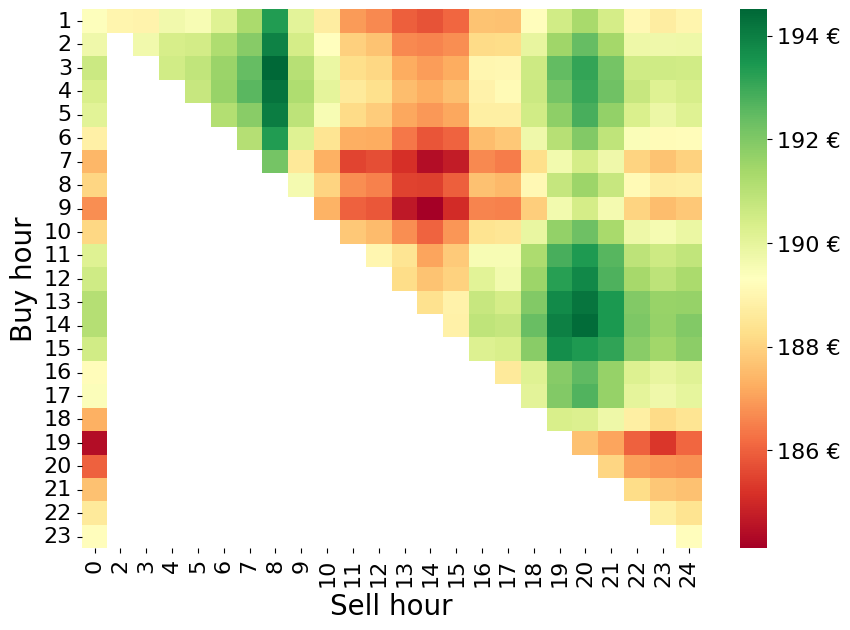

In [10]:
name = "heatmap_profit"

from matplotlib.ticker import FuncFormatter

heat_profit = df[
    (df["combo_id"] != 0)
].pivot_table(
    index="buy_hour",
    columns="sell_hour",
    values="profit",
    aggfunc="mean"
)


plt.figure(figsize=(10, 7))

vmin = heat_profit.min().min() 
vmax = heat_profit.max().max()

ax = sns.heatmap(heat_profit, cmap="RdYlGn", vmin=vmin, vmax=vmax)

# Achsenlabels
ax.set_xlabel("Sell hour", fontsize=20)
ax.set_ylabel("Buy hour", fontsize=20)

# Tick labels
ax.tick_params(axis='both', labelsize=16)

ax.set_xticklabels([int(x) for x in heat_profit.columns])
ax.set_yticklabels([int(y) for y in heat_profit.index])

# Colorbar
cbar = ax.collections[0].colorbar
#cbar.set_label("Profit (€)", fontsize=18)
cbar.ax.tick_params(labelsize=16)

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f} €"))

filepath = os.path.join(folder, f"{name}_{year}.png")
plt.savefig(filepath, dpi=300, bbox_inches='tight')

plt.show()

#### Heatmap performance vs RI baseline

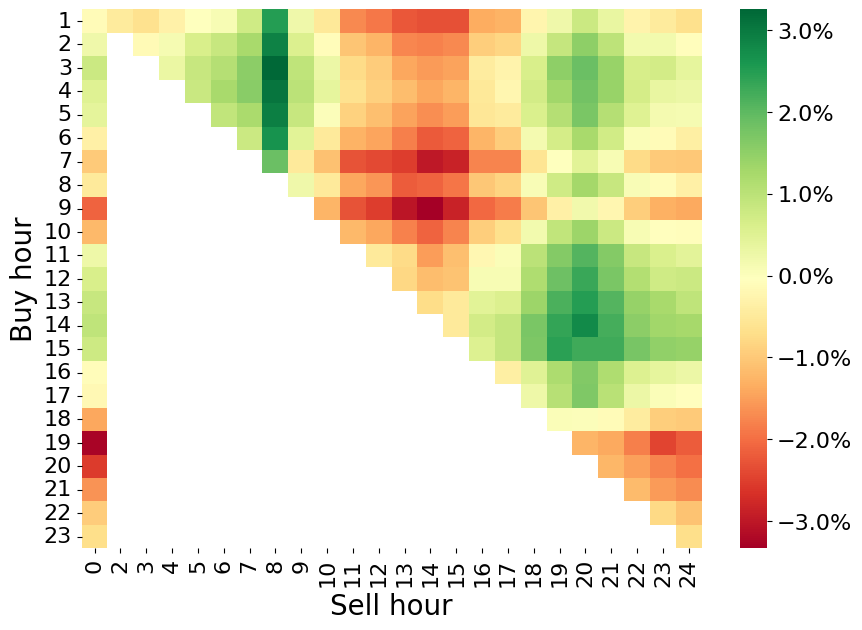

In [11]:
name = "heatmap_uplift_ri_base_"

from matplotlib.ticker import PercentFormatter
from matplotlib.ticker import FuncFormatter

heat_mean = df[
    (df["combo_id"] != 0)
].pivot_table(
    index="buy_hour",
    columns="sell_hour",
    values="uplift_ri_base_pct",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))

vmin = heat_mean.min().min() 
vmax = heat_mean.max().max()

ax = sns.heatmap(heat_mean, cmap="RdYlGn", vmin=vmin, vmax=vmax)

# Achsenlabels
ax.set_xlabel("Sell hour", fontsize=20)
ax.set_ylabel("Buy hour", fontsize=20)

# Tick labels
ax.tick_params(axis='both', labelsize=16)

ax.set_xticklabels([int(x) for x in heat_mean.columns])
ax.set_yticklabels([int(y) for y in heat_mean.index])

# Colorbar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)

#cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x*100:.0f}"))
#cbar.set_label("Uplift (%)", fontsize=18)

cbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))


filepath = os.path.join(folder, f"{name}_{year}.png")
plt.savefig(filepath, dpi=300, bbox_inches='tight')

plt.show()

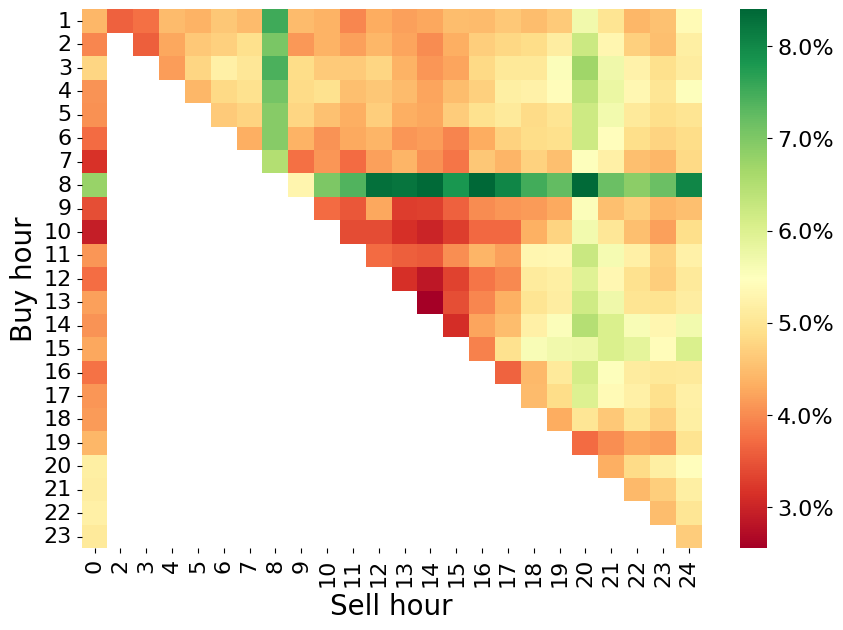

In [12]:
name = "heatmap_uplift_positive_ri_base"


from matplotlib.ticker import PercentFormatter

heat_mean = df[
    (df["combo_id"] != 0) & (df["uplift_ri_base_pct"] > 0)
].pivot_table(
    index="buy_hour",
    columns="sell_hour",
    values="uplift_ri_base_pct",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))

vmin = heat_mean.min().min() 
vmax = heat_mean.max().max()

ax = sns.heatmap(heat_mean, cmap="RdYlGn", vmin=vmin, vmax=vmax)

# Achsenlabels
ax.set_xlabel("Sell hour", fontsize=20)
ax.set_ylabel("Buy hour", fontsize=20)

# Tick labels
ax.tick_params(axis='both', labelsize=16)

ax.set_xticklabels([int(x) for x in heat_mean.columns])
ax.set_yticklabels([int(y) for y in heat_mean.index])

# Colorbar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
cbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))



filepath = os.path.join(folder, f"{name}_{year}.png")
plt.savefig(filepath, dpi=300, bbox_inches='tight')

plt.show()

#### Heatmap performance vs myopic baseline

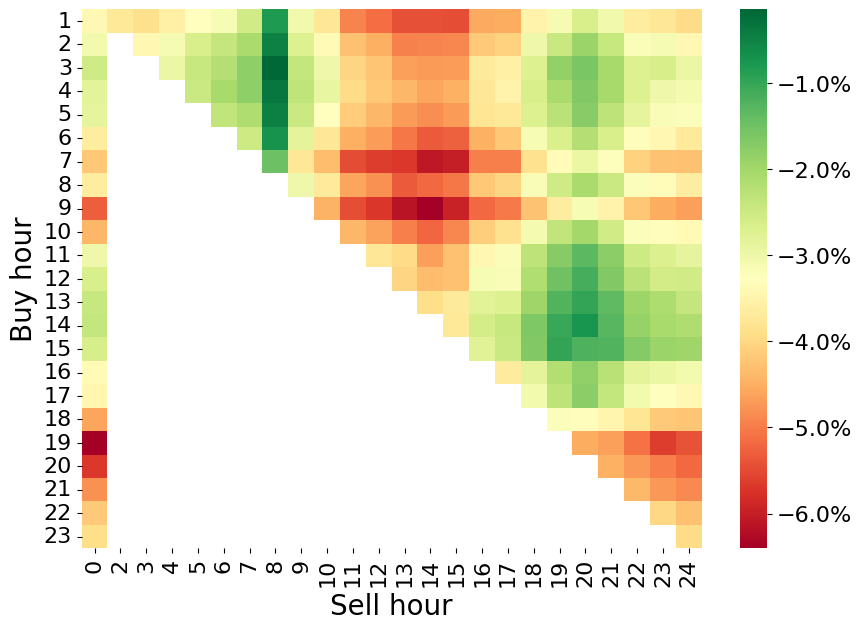

In [13]:
name = "heatmap_uplift_myopic_base"

from matplotlib.ticker import PercentFormatter

heat_mean = df[
    (df["combo_id"] != 0)
].pivot_table(
    index="buy_hour",
    columns="sell_hour",
    values="uplift_myopic_pct",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))

vmin = heat_mean.min().min() 
vmax = heat_mean.max().max()

ax = sns.heatmap(heat_mean, cmap="RdYlGn", vmin=vmin, vmax=vmax)

# Achsenlabels
ax.set_xlabel("Sell hour", fontsize=20)
ax.set_ylabel("Buy hour", fontsize=20)

# Tick labels
ax.tick_params(axis='both', labelsize=16)

ax.set_xticklabels([int(x) for x in heat_mean.columns])
ax.set_yticklabels([int(y) for y in heat_mean.index])

# Colorbar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
cbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))



filepath = os.path.join(folder, f"{name}_{year}.png")
plt.savefig(filepath, dpi=300, bbox_inches='tight')

plt.show()

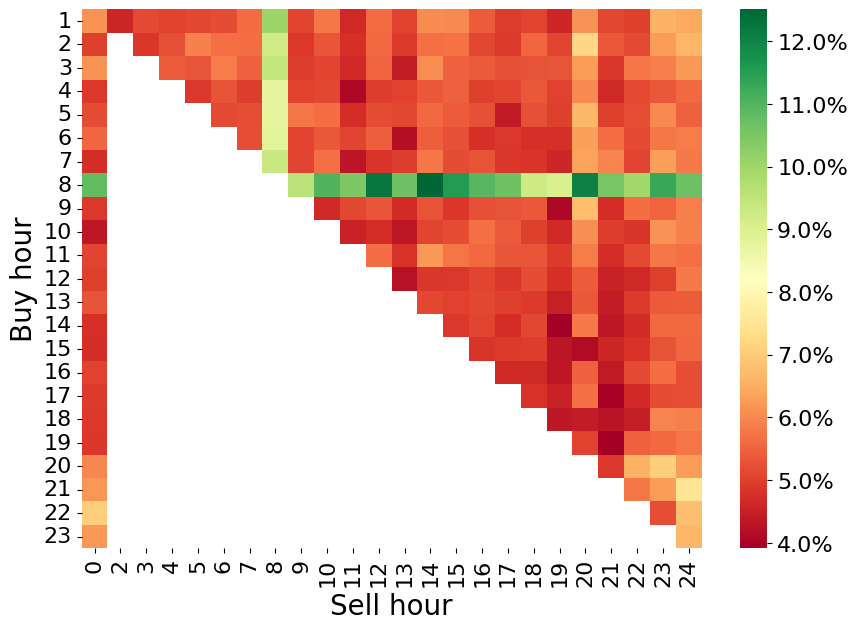

In [14]:
name= "heatmap_uplift_positive_myopic_base"

from matplotlib.ticker import PercentFormatter

heat_mean = df[
    (df["combo_id"] != 0) & (df["uplift_myopic_pct"] > 0)
].pivot_table(
    index="buy_hour",
    columns="sell_hour",
    values="uplift_myopic_pct",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))

vmin = heat_mean.min().min() 
vmax = heat_mean.max().max()

ax = sns.heatmap(heat_mean, cmap="RdYlGn", vmin=vmin, vmax=vmax)

# Achsenlabels
ax.set_xlabel("Sell hour", fontsize=20)
ax.set_ylabel("Buy hour", fontsize=20)

# Tick labels
ax.tick_params(axis='both', labelsize=16)

ax.set_xticklabels([int(x) for x in heat_mean.columns])
ax.set_yticklabels([int(y) for y in heat_mean.index])

# Colorbar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
cbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))




filepath = os.path.join(folder, f"{name}_{year}.png")
plt.savefig(filepath, dpi=300, bbox_inches='tight')
plt.show()

#### Holding time

In [15]:
df["holding_time"] = df["sell_hour"] - df["buy_hour"]

df.groupby("holding_time")["uplift_ri_base_pct"].agg(
    mean="mean",
    median="median",
    count="count"
).reset_index()

,holding_time,mean,median,count
0,-23.0,-0.006850,-0.000516,273
1,-22.0,-0.009600,-0.006172,273
2,-21.0,-0.016108,-0.012148,273
3,-20.0,-0.025587,-0.010871,273
4,-19.0,-0.032672,-0.016315,273
5,-18.0,-0.014092,-0.003146,273
6,-17.0,-0.001931,0.003419,273
7,-16.0,-0.000995,0.003624,273
8,-15.0,0.007611,0.012828,273
9,-14.0,0.009529,0.010448,273


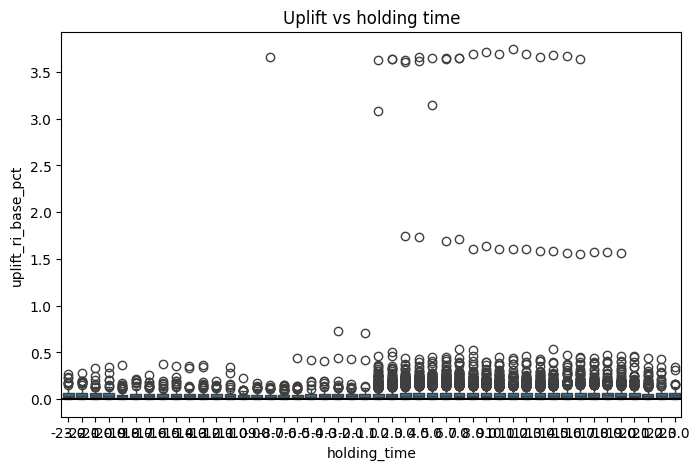

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x="holding_time", y="uplift_ri_base_pct", data=df[df["uplift_ri_base_pct"]>0])
plt.axhline(0, color="black")
plt.title("Uplift vs holding time")
plt.show()

In [17]:
df.groupby("buy_hour")["uplift_ri_base_pct"].agg(
    mean="mean",
    median="median",
    success_rate=lambda x: (x > 0).mean(),
    count="count"
)

,mean,median,success_rate,count
buy_hour,,,,
0.0,0.000000,0.000000,0.000000,273
1.0,-0.005005,-0.003277,0.473291,6552
2.0,0.000377,0.001525,0.514095,6279
3.0,0.004253,0.004168,0.531136,6006
4.0,0.004283,0.004485,0.536368,5733
5.0,0.001970,0.002731,0.521062,5460
6.0,-0.003007,-0.001100,0.493156,5187
7.0,-0.011162,-0.010519,0.421042,4914
8.0,-0.005450,-0.014181,0.388925,4641


In [18]:
df.groupby("sell_hour")["uplift_ri_base_pct"].agg(
    mean="mean",
    median="median",
    success_rate=lambda x: (x > 0).mean(),
    count="count"
)

,mean,median,success_rate,count
sell_hour,,,,
0.0,-0.004443,0.000000,0.482753,6552
2.0,-0.004730,-0.001229,0.494505,273
3.0,-0.004023,-0.001419,0.492674,546
4.0,0.000336,0.000107,0.503053,819
5.0,0.005600,0.003539,0.530220,1092
6.0,0.008436,0.010258,0.580952,1365
7.0,0.011821,0.012776,0.612943,1638
8.0,0.027364,0.013850,0.624804,1911
9.0,0.004781,0.005730,0.553114,2184


#### Best trading patterns

In [19]:
q = df["uplift_ri_base_abs"].quantile(0.95)
top = df[df["uplift_ri_base_abs"] >= q]

top.groupby(["buy_hour", "sell_hour"]).size().sort_values(ascending=False)

buy_hour  sell_hour
4.0       19.0         29
13.0      19.0         27
3.0       19.0         27
5.0       19.0         27
14.0      19.0         25
                       ..
8.0       15.0          4
9.0       0.0           3
7.0       0.0           3
8.0       0.0           2
13.0      14.0          1
Length: 299, dtype: int64

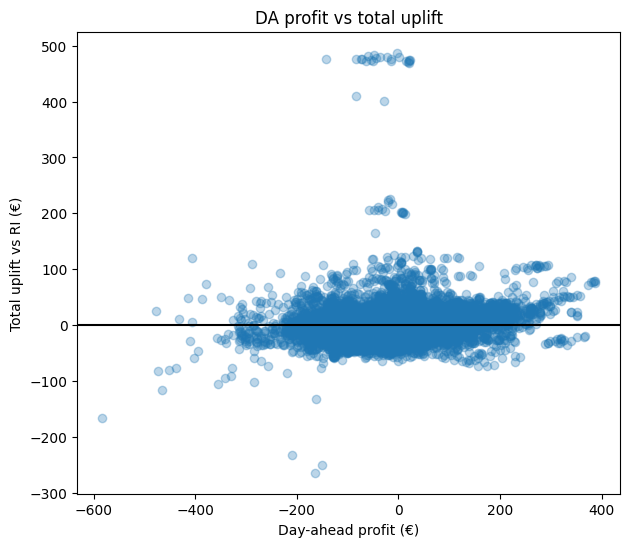

In [20]:
plt.figure(figsize=(7,6))
plt.scatter(df["da_profit"], df["uplift_ri_base_abs"], alpha=0.3)
plt.axhline(0, color="black")
plt.xlabel("Day-ahead profit (€)")
plt.ylabel("Total uplift vs RI (€)")
plt.title("DA profit vs total uplift")
plt.show()

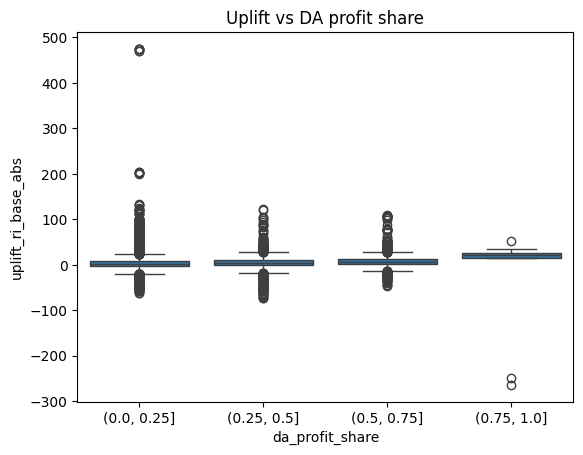

In [21]:
sns.boxplot(x=pd.cut(df["da_profit_share"], bins=[0,0.25,0.5,0.75,1]),
            y=df["uplift_ri_base_abs"])
plt.title("Uplift vs DA profit share")
plt.show()

In [22]:
 g = (df[df.combo_id != 0]
     .groupby(["buy_hour","sell_hour"])
     .apply(lambda x: pd.Series({
         "success_rate": (x.uplift_ri_base_pct > 0).mean(),
         "mean": x.uplift_ri_base_pct.mean(),
         "p05": x.uplift_ri_base_pct.quantile(0.05),
         "p25": x.uplift_ri_base_pct.quantile(0.25),
         "p50": x.uplift_ri_base_pct.quantile(0.5),
         "p75": x.uplift_ri_base_pct.quantile(0.75),
         "p95": x.uplift_ri_base_pct.quantile(0.95),
         "p99": x.uplift_ri_base_pct.quantile(0.99),
         "n": len(x),
     }))
     .reset_index())

pairs = g.to_dict("records")
pareto = []
for i,a in enumerate(pairs):
    dominated = False
    for j,b in enumerate(pairs):
        if i==j: 
            continue
        if (b["success_rate"] >= a["success_rate"] and b["p95"] >= a["p95"]
            and (b["success_rate"] > a["success_rate"] or b["p95"] > a["p95"])):
            dominated = True
            break
    if not dominated:
        pareto.append(a)
pareto_df = pd.DataFrame(pareto).sort_values(["success_rate","p95"], ascending=False)

pareto_df

/var/folders/83/hxkk8qrs62xfzh1l_vbb4grc0000gn/T/ipykernel_43491/3281133281.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,buy_hour,sell_hour,success_rate,mean,p05,p25,p50,p75,p95,p99,n
2,13.0,19.0,0.714286,0.021521,-0.085007,-0.002772,0.027869,0.060787,0.113813,0.157889,273.0
3,14.0,19.0,0.699634,0.023758,-0.077980,-0.006435,0.030881,0.059764,0.122320,0.164659,273.0
0,3.0,8.0,0.644689,0.032545,-0.083353,-0.011936,0.017367,0.050478,0.125205,0.254713,273.0
1,3.0,19.0,0.630037,0.015151,-0.104057,-0.026614,0.017530,0.055344,0.125973,0.180269,273.0
4,15.0,24.0,0.619048,0.014447,-0.110326,-0.018338,0.018554,0.058539,0.131734,0.198718,273.0


In [23]:
syn = df[df.combo_id != 0].copy()

topk = (syn.sort_values(["day","uplift_ri_base_pct"], ascending=[True, False])
          .groupby("day")
          .head(5))

counts = (topk.groupby(["buy_hour","sell_hour"])
              .size()
              .sort_values(ascending=False)
              .head(20))
counts


buy_hour  sell_hour
14.0      21.0         19
11.0      20.0         16
13.0      21.0         16
17.0      19.0         15
12.0      21.0         14
14.0      20.0         14
15.0      24.0         14
22.0      0.0          13
17.0      20.0         13
14.0      19.0         13
1.0       8.0          13
13.0      20.0         13
3.0       8.0          12
23.0      0.0          12
21.0      0.0          12
12.0      18.0         12
11.0      18.0         12
15.0      19.0         12
          18.0         11
          21.0         11
dtype: int64

In [24]:
def cvar(x, alpha=0.1):
    q = x.quantile(alpha)
    return x[x <= q].mean()

risk = (syn.groupby(["buy_hour","sell_hour"])["uplift_ri_base_pct"]
          .apply(lambda x: pd.Series({
              "mean": x.mean(),
              "cvar10": cvar(x, 0.1),
              "p95": x.quantile(0.95),
              "success": (x>0).mean(),
          }))
          .reset_index())
risk

,buy_hour,sell_hour,level_2,uplift_ri_base_pct
0,1.0,0.0,mean,-0.001324
1,1.0,0.0,cvar10,-0.107632
2,1.0,0.0,p95,0.089584
3,1.0,0.0,success,0.439560
4,1.0,2.0,mean,-0.004730
...,...,...,...,...
1191,23.0,0.0,success,0.494505
1192,23.0,24.0,mean,-0.007066
1193,23.0,24.0,cvar10,-0.165608
1194,23.0,24.0,p95,0.090444
